In [1]:
import librosa
import librosa.display
import IPython.display as ipd
import scipy as super
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sound1 = r"C:\Users\User\OneDrive\Desktop\major project\acoustic_audio\Bearded_Seal\7202100T.wav"
sound2 = r"C:\Users\User\OneDrive\Desktop\major project\acoustic_audio\Grampus_Rissos_Dolphin\5902900A.wav"
sound3 = r"C:\Users\User\OneDrive\Desktop\major project\acoustic_audio\Common_Dolphin\5801400J.wav"

In [3]:
ipd.Audio(sound1)

In [4]:
ipd.Audio(sound2)

In [5]:
ipd.Audio(sound3)

In [6]:
sound_1, sr1 = librosa.load(sound1)
sound_2, sr2 = librosa.load(sound2)
sound_3, sr3 = librosa.load(sound3)

In [7]:
type(sound_1)

numpy.ndarray

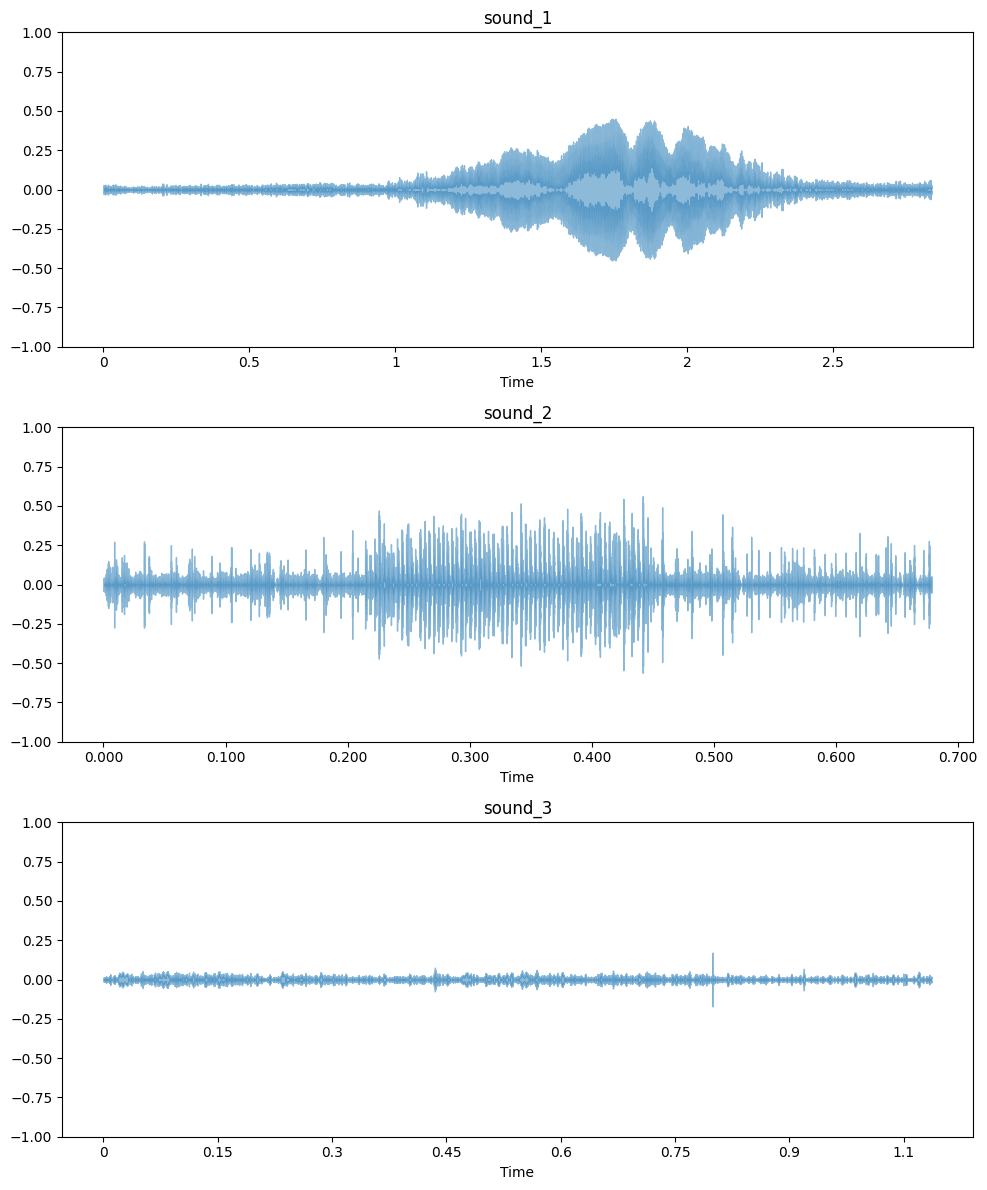

Time vs Amplitude


In [8]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Assuming you have sound_1, sound_2, sound_3 and the same sample rate sr
plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1)
librosa.display.waveshow(sound_1, sr=sr1, alpha=0.5)
plt.title("sound_1")
plt.ylim(-1, 1)

plt.subplot(3, 1, 2)
librosa.display.waveshow(sound_2, sr=sr2, alpha=0.5)
plt.title("sound_2")
plt.ylim(-1, 1)

plt.subplot(3, 1, 3)
librosa.display.waveshow(sound_3, sr=sr3, alpha=0.5)
plt.title("sound_3")
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()

print("Time vs Amplitude")


# Forier Transform

In [9]:
# deriving spectrum using forier transform
ft = super.fft.fft(sound_1)
magnitude = np.absolute(ft)
frequency = np.linspace(0, sr1, len(magnitude))

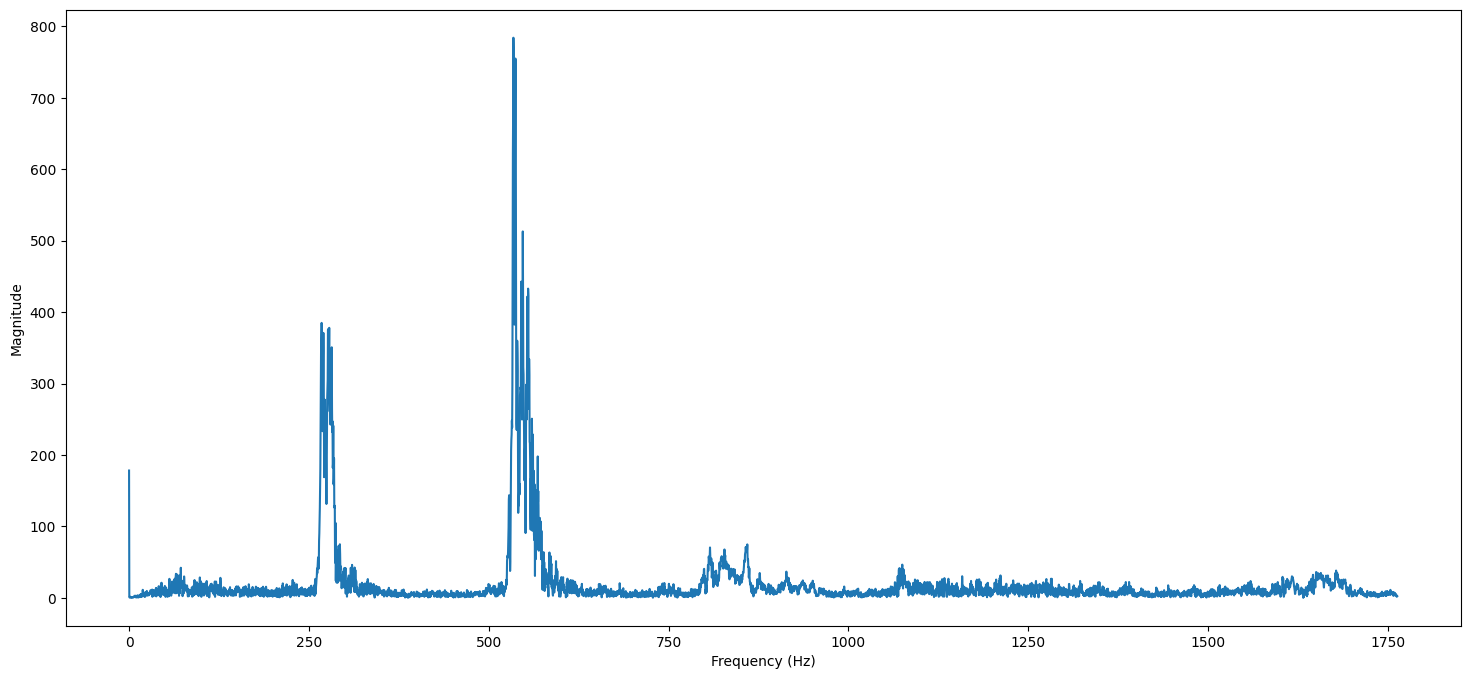

In [10]:
plt.figure(figsize=(18,8))
plt.plot(frequency[:5000], magnitude[:5000])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

# Short Time fourier Transform

In [11]:
FRAME_SIZE = 2048
HOP_SIZE = 512

In [12]:
S_scale = librosa.stft(sound_1, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)

# Calculating the spectrogram

In [13]:
Y_scale = np.abs(S_scale) ** 2


# Visualizing the spectrogram

In [14]:

def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(25, 10))
    librosa.display.specshow(Y, 
                             sr=sr, 
                             hop_length=hop_length, 
                             x_axis="time", 
                             y_axis=y_axis)
    plt.colorbar(format="%+2.f")

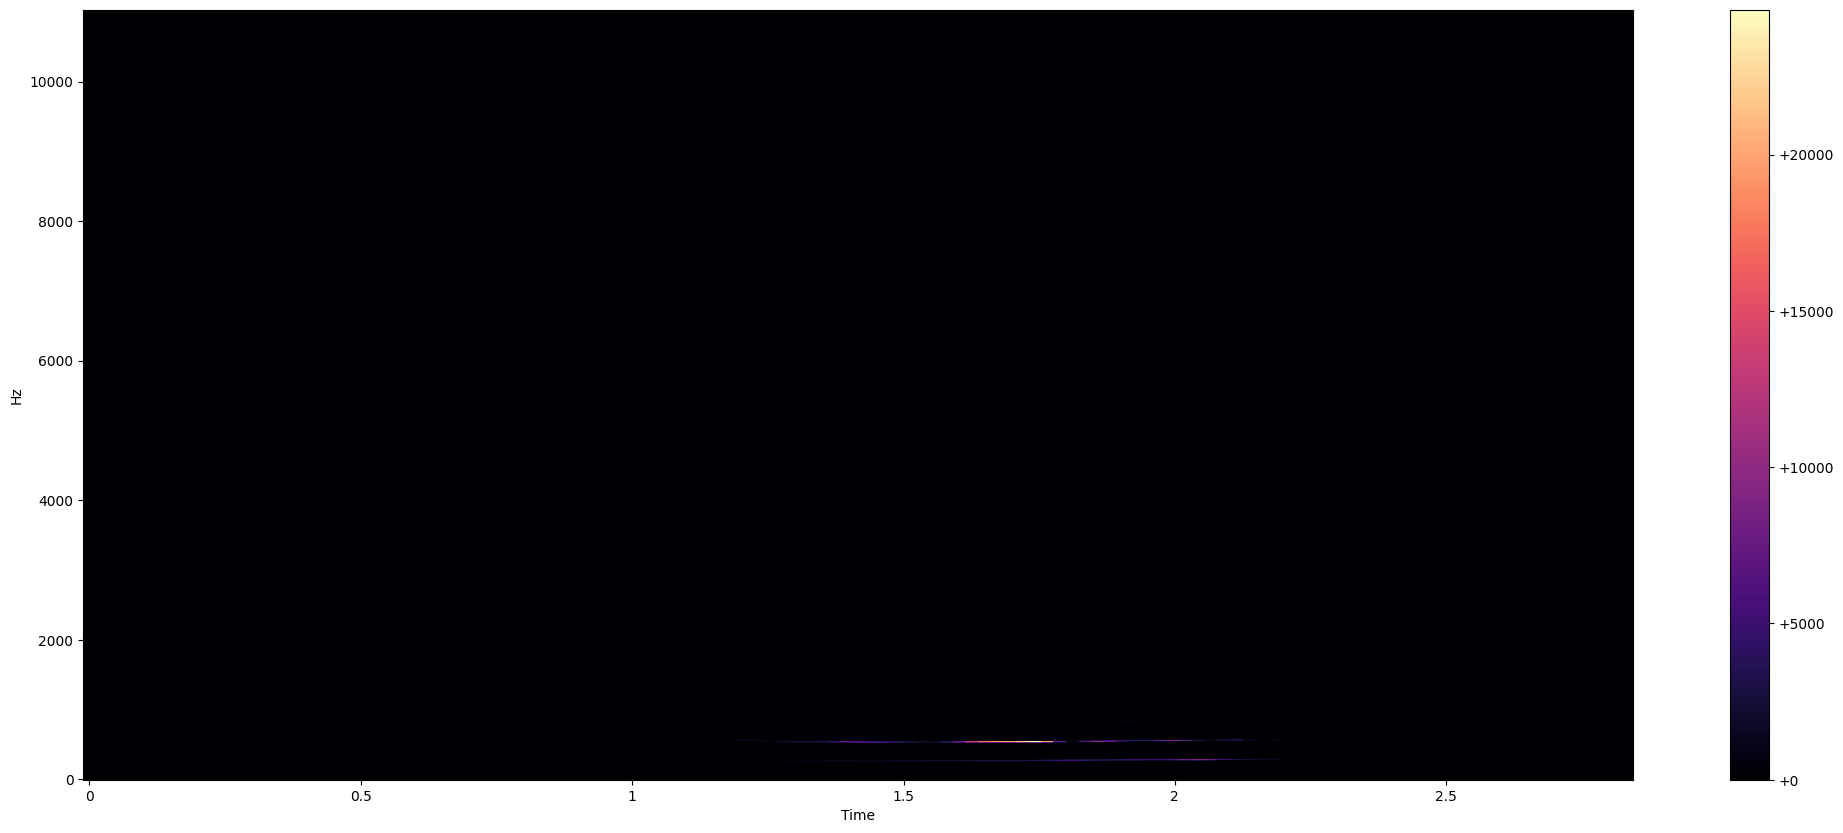

In [15]:

plot_spectrogram(Y_scale, sr1, HOP_SIZE)

# Log-Amplitude Spectrogram

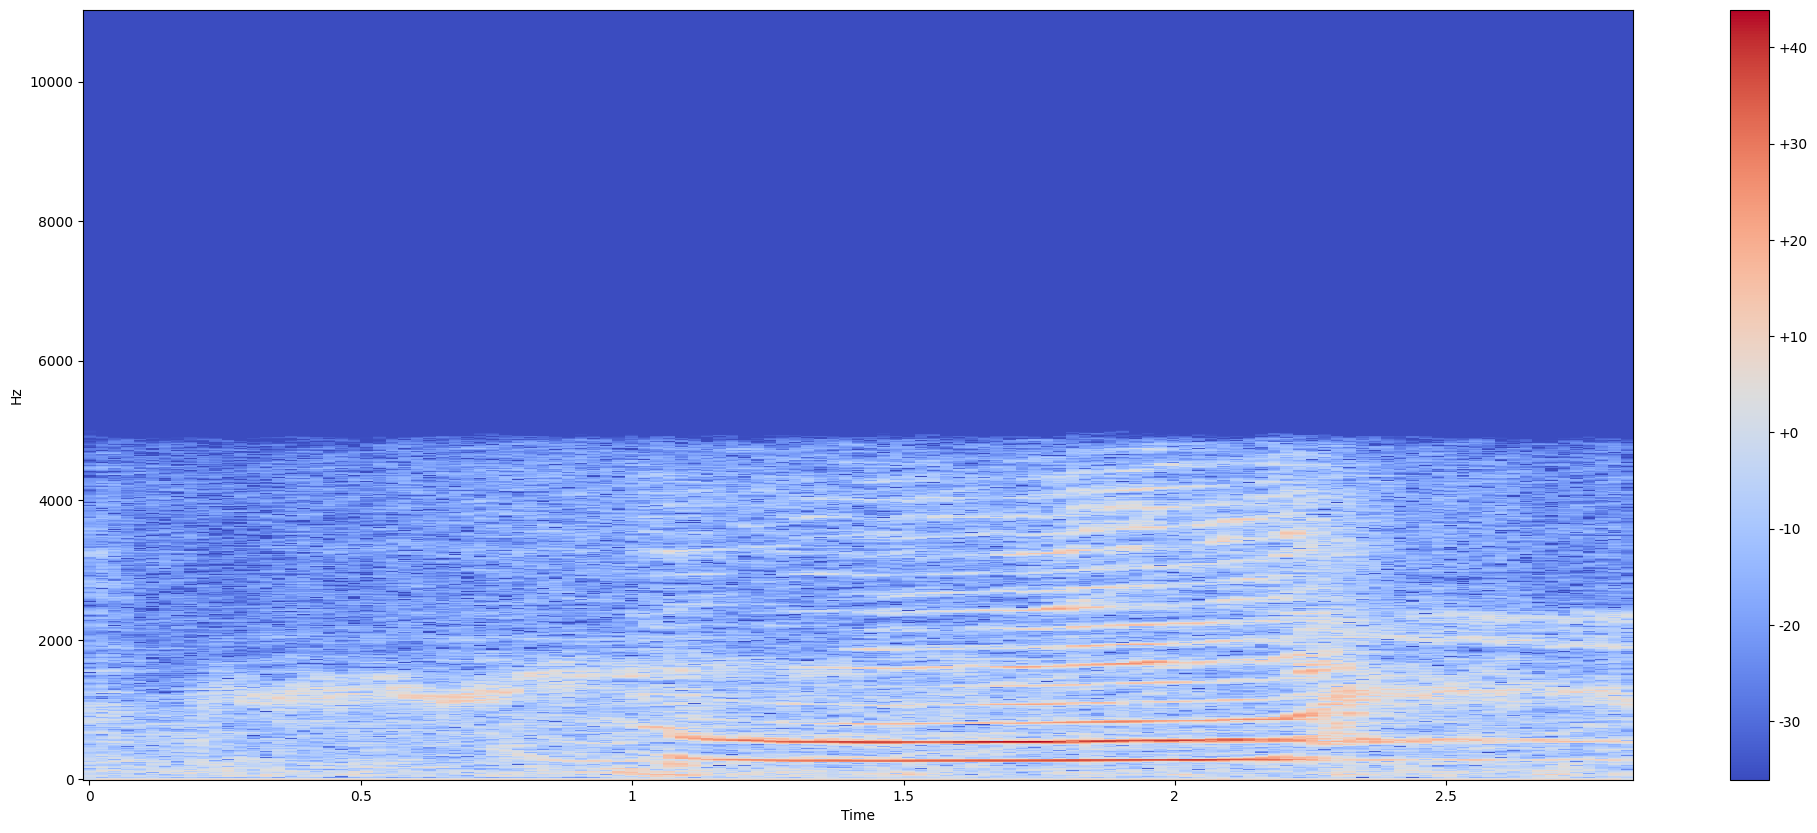

In [16]:
Y_log_scale = librosa.power_to_db(Y_scale)
plot_spectrogram(Y_log_scale, sr1, HOP_SIZE)

# Log-Frequency Spectrogram

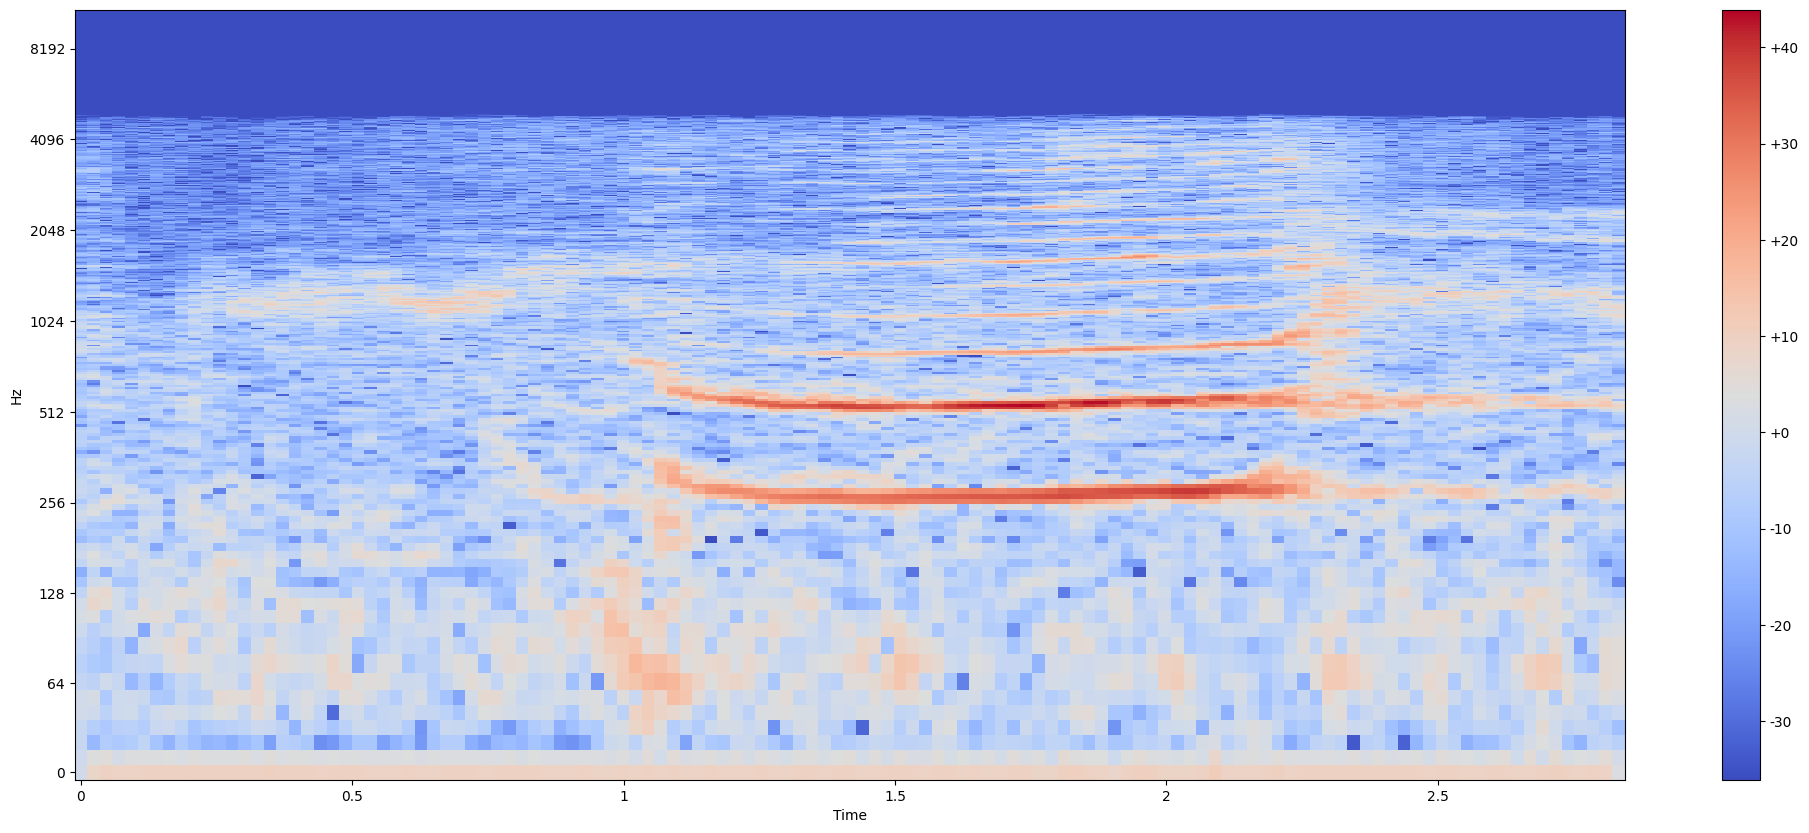

In [17]:

plot_spectrogram(Y_log_scale, sr1, HOP_SIZE, y_axis="log")

In [18]:
mel_spectrogram = librosa.feature.melspectrogram(y=sound_1, sr=sr1, n_fft=2048, hop_length=512, n_mels=10)


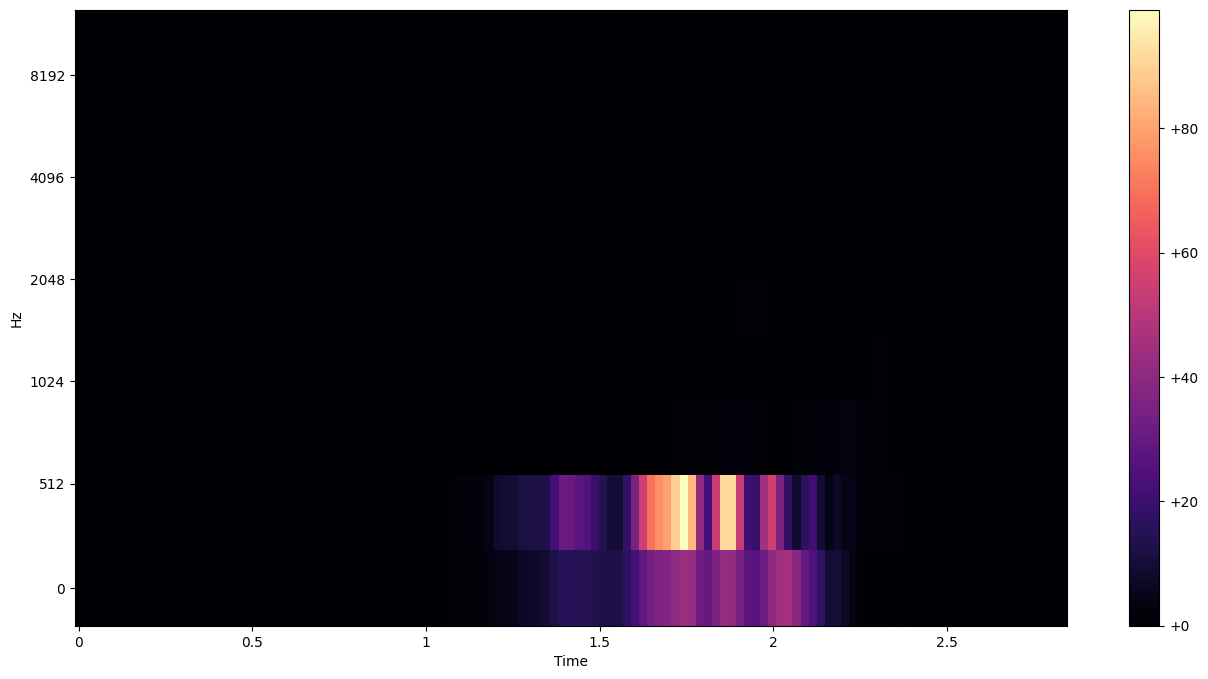

In [19]:
plt.figure(figsize=(16, 8))
librosa.display.specshow(mel_spectrogram, 
                         x_axis="time",
                         y_axis="mel", 
                         sr=sr1)
plt.colorbar(format="%+2.f")
plt.show()

In [20]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

path = r"C:\Users\User\OneDrive\Desktop\major project\acoustic_audio\Atlantic_Spotted_Dolphin\6102500A.wav"

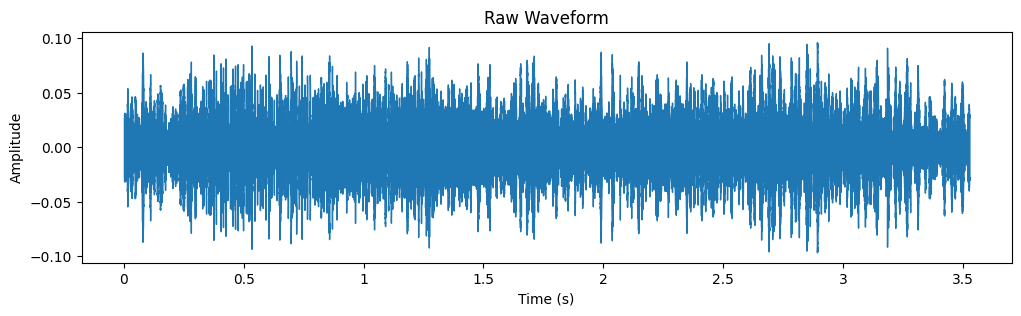

In [21]:
# 1) Load audio
y, sr = librosa.load(path, sr=16000, mono=True)

plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Raw Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

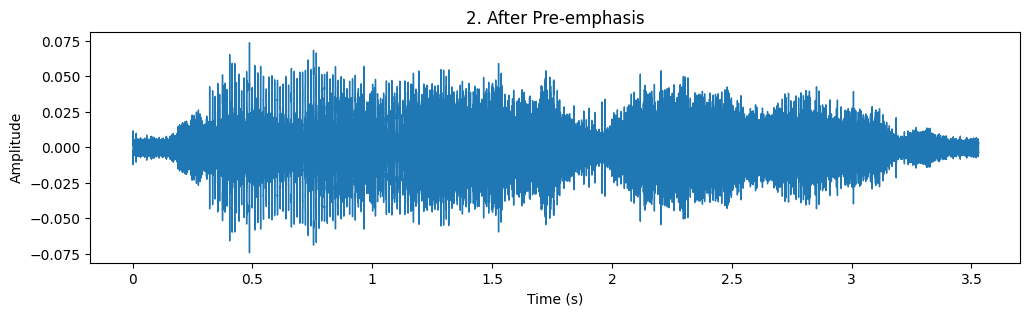

In [22]:
# 2) Pre-emphasis
pre_emphasis = 0.97
y_pre = np.append(y[0], y[1:] - pre_emphasis * y[:-1])

plt.figure(figsize=(12, 3))
librosa.display.waveshow(y_pre, sr=sr)
plt.title("2. After Pre-emphasis")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

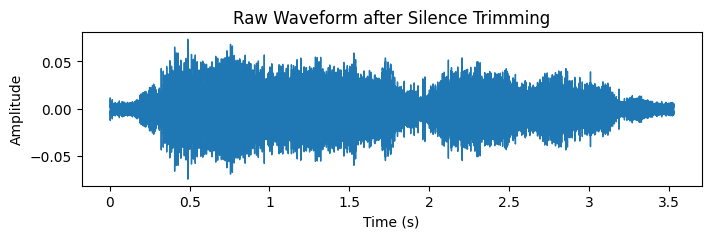

In [29]:
# 3) Trim silence
y_trim, _ = librosa.effects.trim(y_pre, top_db=20)

plt.figure(figsize=(8, 2))
librosa.display.waveshow(y_trim, sr=sr)
plt.title("Raw Waveform after Silence Trimming")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

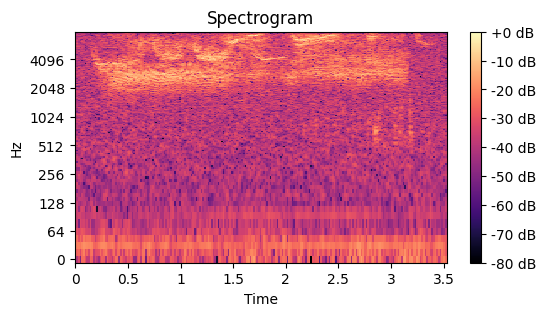

In [24]:
# 4) STFT (spectrogram before Mel)
D = np.abs(librosa.stft(y_trim, n_fft=1024, hop_length=256))

plt.figure(figsize=(6, 3))
librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max),
                         sr=sr, hop_length=256, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

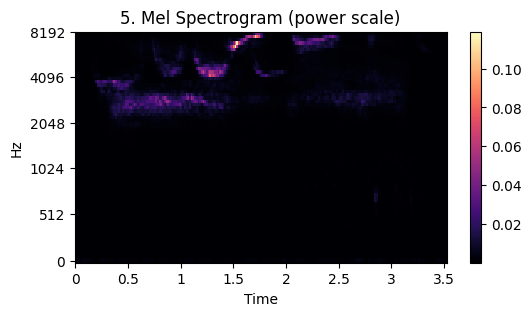

In [25]:
# 5) Mel spectrogram (power)
S = librosa.feature.melspectrogram(y=y_trim, sr=sr,
                                   n_fft=1024, hop_length=256,
                                   n_mels=64, fmin=0, fmax=8000)

plt.figure(figsize=(6, 3))
librosa.display.specshow(S, sr=sr, hop_length=256,
                         x_axis="time", y_axis="mel")
plt.colorbar()
plt.title("5. Mel Spectrogram (power scale)")
plt.show()

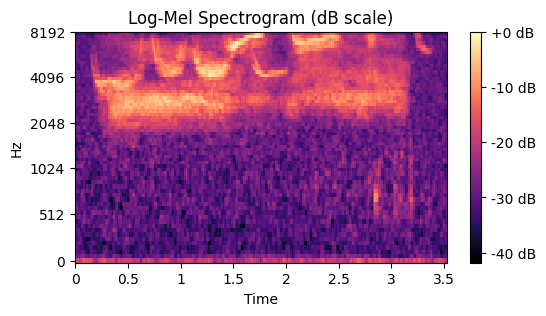

In [26]:
# 6) Convert to dB (log-Mel)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(6, 3))
librosa.display.specshow(S_db, sr=sr, hop_length=256,
                         x_axis="time", y_axis="mel", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram (dB scale)")
plt.show()

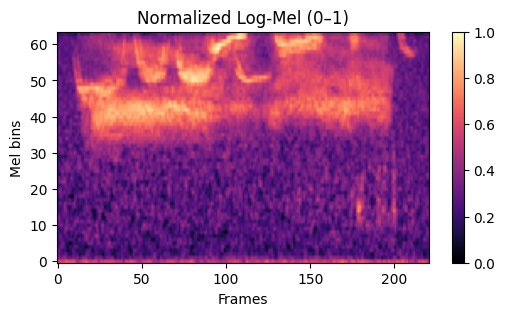

In [27]:
# 7) Normalize to 0–1
S_min, S_max = S_db.min(), S_db.max()
S_norm = (S_db - S_min) / (S_max - S_min + 1e-8)

plt.figure(figsize=(6, 3))
plt.imshow(S_norm, origin="lower", aspect="auto", cmap="magma")
plt.colorbar()
plt.title("Normalized Log-Mel (0–1)")
plt.xlabel("Frames")
plt.ylabel("Mel bins")
plt.show()
